### The following cell defines the "listen" function to simplify the listening avoiding the download. Don't modify it.

In [ ]:
from IPython.display import HTML as __HTML
try:
    ___tups = __tups; del ___tups
except NameError:
    __tups = True; display(__HTML("<script>if(!window.stopOthersAdded){window.stopOthersAdded=!0;function stopOthers(currentAudio){document.querySelectorAll('audio').forEach(audio=>{if(audio!==currentAudio){audio.pause()}})}}</script>"))
def listen(src: str):
    display(__HTML(f"<audio controls onplay=\"stopOthers(this)\"><source src=\"{src}\">Your browser does not support the audio element. </audio>"))



# Lab 1

**Course:** Music and Multimedia Streaming over the Internet  
**Exercise:** Exercise 1 – FFmpeg  
**Student:** MEHRAN BAYAT  
**Student ID:** S320636  

This notebook reports the complete solution of Exercise 1. The work follows the exact order required by the lab:

1. encode `dogs.wav` into six compressed files;
2. convert the six compressed files back to uncompressed WAV;
3. prove that the FLAC version is sample-wise identical to the original;
4. compute the error signals and the requested metrics for files 1–5;
5. generate the error files for files 1 and 5;
6. listen to the error files and comment on the results.

---



## Team Members

- **MEHRAN BAYAT** — **Student ID: S320636**



## 2.1 Using FFmpeg

The original file `dogs.wav` was converted into the six required compressed versions using the following FFmpeg command strings:

```bash
ffmpeg -y -i dogs.wav -c:a libmp3lame -b:a 320k dogs_1_mp3_cbr_320.mp3
ffmpeg -y -i dogs.wav -c:a libmp3lame -b:a 96k  dogs_2_mp3_cbr_096.mp3
ffmpeg -y -i dogs.wav -c:a libmp3lame -q:a 0    dogs_3_mp3_vbr_max.mp3
ffmpeg -y -i dogs.wav -c:a libopus    -b:a 256k dogs_4_opus_256.opus
ffmpeg -y -i dogs.wav -c:a libopus    -b:a 48k  dogs_5_opus_048.opus
ffmpeg -y -i dogs.wav -c:a flac -compression_level 12 dogs_6_flac_max.flac
```

These commands generate exactly the six files requested by the lab:

1. MP3 – CBR at 320 kbps  
2. MP3 – CBR at 96 kbps  
3. MP3 – VBR maximum quality  
4. Opus at 256 kbps  
5. Opus at 48 kbps  
6. FLAC with maximum compression level  

The selected codec options are consistent with the lab specification:
- `libmp3lame` for MP3,
- `libopus` for Opus,
- `flac` for FLAC.



## 2.2 Analyzing outputs

In this section, the six encoded files are first converted back to WAV and then compared against the original signal `dogs.wav`.

### 1. Converting one encoded file back to WAV

One example FFmpeg command used to convert an encoded file back to uncompressed WAV is:

```bash
ffmpeg -y -i dogs_1_mp3_cbr_320.mp3 dogs_1_mp3_cbr_320_dec.wav
```

For completeness, the full set of decoding commands used in the notebook is:

```bash
ffmpeg -y -i dogs_1_mp3_cbr_320.mp3  dogs_1_mp3_cbr_320_dec.wav
ffmpeg -y -i dogs_2_mp3_cbr_096.mp3  dogs_2_mp3_cbr_096_dec.wav
ffmpeg -y -i dogs_3_mp3_vbr_max.mp3  dogs_3_mp3_vbr_max_dec.wav
ffmpeg -y -i dogs_4_opus_256.opus    dogs_4_opus_256_dec.wav
ffmpeg -y -i dogs_5_opus_048.opus    dogs_5_opus_048_dec.wav
ffmpeg -y -i dogs_6_flac_max.flac    dogs_6_flac_max_dec.wav
```

### 2. Metrics to be computed

For the lossy files (1 to 5), the following metrics are computed exactly as required by the assignment:

\[
\mathrm{MAE} = \frac{1}{N}\sum_{i=0}^{N} |y_i - x_i|
\]

\[
\mathrm{MSE} = \frac{1}{N}\sum_{i=0}^{N}(y_i - x_i)^2
\]

\[
\mathrm{SNR} = 10 \log_{10}\left(\frac{P_{\mathrm{signal}}}{P_{\mathrm{noise}}}\right)
\]

with

\[
P_{\mathrm{noise}} = \mathrm{MSE}
\qquad \text{and} \qquad
P_{\mathrm{signal}} = \frac{1}{N}\sum_{i=0}^{N}x_i^2
\]

where:
- \(x\) is the original signal,
- \(y\) is the decoded compressed signal,
- \(N\) is the total number of samples.

As suggested by the lab, the error signal is first computed as:

\[
e = y - x
\]

This error signal is then used both for the numerical metrics and for the generation of the error audio files.


In [1]:
import numpy as np
import pandas as pd
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

In [2]:
sample_rate, samples_original = wav.read('dogs.wav')

sr1, samples_1 = wav.read('dogs_1_mp3_cbr_320_dec.wav')
sr2, samples_2 = wav.read('dogs_2_mp3_cbr_096_dec.wav')
sr3, samples_3 = wav.read('dogs_3_mp3_vbr_max_dec.wav')
sr4, samples_4 = wav.read('dogs_4_opus_256_dec.wav')
sr5, samples_5 = wav.read('dogs_5_opus_048_dec.wav')
sr6, samples_6 = wav.read('dogs_6_flac_max_dec.wav')

print('Original:', sample_rate, samples_original.shape, samples_original.dtype)
print('1 MP3 CBR 320:', sr1, samples_1.shape, samples_1.dtype)
print('2 MP3 CBR 96:', sr2, samples_2.shape, samples_2.dtype)
print('3 MP3 VBR max:', sr3, samples_3.shape, samples_3.dtype)
print('4 Opus 256:', sr4, samples_4.shape, samples_4.dtype)
print('5 Opus 48:', sr5, samples_5.shape, samples_5.dtype)
print('6 FLAC max:', sr6, samples_6.shape, samples_6.dtype)

Original: 48000 (1364219,) int16
1 MP3 CBR 320: 48000 (1364219,) int16
2 MP3 CBR 96: 48000 (1364219,) int16
3 MP3 VBR max: 48000 (1364219,) int16
4 Opus 256: 48000 (1364219,) int16
5 Opus 48: 48000 (1364219,) int16
6 FLAC max: 48000 (1364219,) int16


In [3]:
assert sample_rate == sr1 == sr2 == sr3 == sr4 == sr5 == sr6
assert samples_original.shape == samples_1.shape == samples_2.shape == samples_3.shape == samples_4.shape == samples_5.shape == samples_6.shape

print('All sample rates match.')
print('All shapes match.')

All sample rates match.
All shapes match.



### 2.2.2 Verification that the FLAC file is lossless

The FLAC-decoded signal is compared directly against the original signal in terms of:
- sample rate,
- shape,
- sample-by-sample equality,
- maximum absolute difference.

If the decoded FLAC file is truly lossless, then every sample must be identical to the original one.


In [4]:
same_sr = (sample_rate == sr6)
same_shape = (samples_original.shape == samples_6.shape)
same_samples = np.array_equal(samples_original, samples_6)
max_abs_diff_flac = np.max(np.abs(samples_6.astype(np.int32) - samples_original.astype(np.int32)))

print('Same sample rate:', same_sr)
print('Same shape:', same_shape)
print('Sample-wise identical:', same_samples)
print('Maximum absolute difference:', max_abs_diff_flac)

Same sample rate: True
Same shape: True
Sample-wise identical: True
Maximum absolute difference: 0



### 2.2.3 Computation of the error signals and the requested metrics

The error signals are computed for files 1 to 5. Then MAE, MSE, and SNR are evaluated using vectorized NumPy operations.


In [5]:
x  = samples_original.astype(np.float64).reshape(-1)
y1 = samples_1.astype(np.float64).reshape(-1)
y2 = samples_2.astype(np.float64).reshape(-1)
y3 = samples_3.astype(np.float64).reshape(-1)
y4 = samples_4.astype(np.float64).reshape(-1)
y5 = samples_5.astype(np.float64).reshape(-1)

N = x.size

e1 = y1 - x
e2 = y2 - x
e3 = y3 - x
e4 = y4 - x
e5 = y5 - x

In [6]:
P_SIGNAL = np.sum(x ** 2) / N

MAE1 = np.sum(np.abs(e1)) / N
MAE2 = np.sum(np.abs(e2)) / N
MAE3 = np.sum(np.abs(e3)) / N
MAE4 = np.sum(np.abs(e4)) / N
MAE5 = np.sum(np.abs(e5)) / N

MSE1 = np.sum(e1 ** 2) / N
MSE2 = np.sum(e2 ** 2) / N
MSE3 = np.sum(e3 ** 2) / N
MSE4 = np.sum(e4 ** 2) / N
MSE5 = np.sum(e5 ** 2) / N

SNR1 = 10 * np.log10(P_SIGNAL / MSE1)
SNR2 = 10 * np.log10(P_SIGNAL / MSE2)
SNR3 = 10 * np.log10(P_SIGNAL / MSE3)
SNR4 = 10 * np.log10(P_SIGNAL / MSE4)
SNR5 = 10 * np.log10(P_SIGNAL / MSE5)

results = pd.DataFrame({
    'File': ['1_MP3_320', '2_MP3_096', '3_MP3_VBR', '4_Opus_256', '5_Opus_048'],
    'MAE': [MAE1, MAE2, MAE3, MAE4, MAE5],
    'MSE': [MSE1, MSE2, MSE3, MSE4, MSE5],
    'SNR_dB': [SNR1, SNR2, SNR3, SNR4, SNR5]
})

results

File,MAE,MSE,SNR_dB
1_MP3_320,6.102702,76.734200,54.099386
2_MP3_096,221.709621,85213.442779,23.644194
3_MP3_VBR,69.738377,9258.827239,33.283715
4_Opus_256,67.165495,8370.095277,33.721971
5_Opus_048,515.549662,465676.278460,16.268434


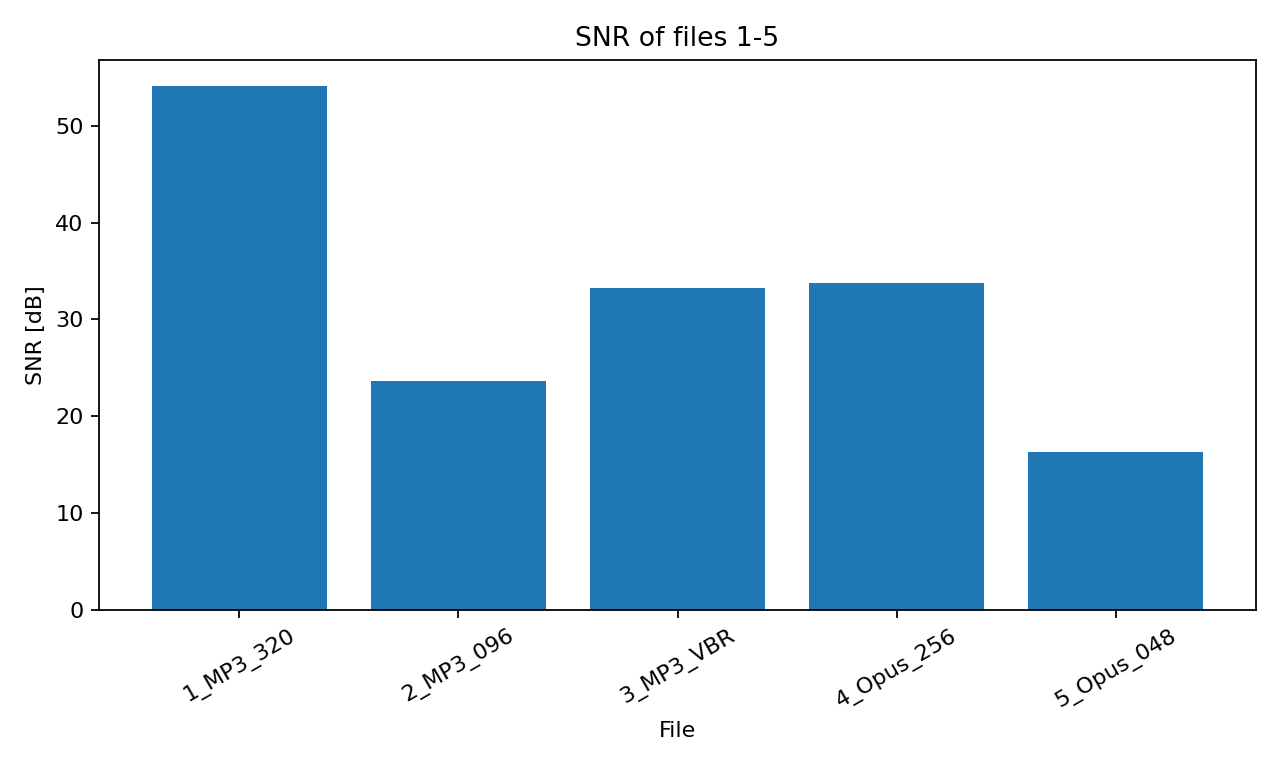

In [7]:
plt.figure(figsize=(8,4))
plt.bar(results['File'], results['SNR_dB'])
plt.title('SNR of files 1-5')
plt.xlabel('File')
plt.ylabel('SNR [dB]')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Discussion of the numerical results

The table and the bar chart show a clear quality ordering among the lossy encodings.

- **File 1 (MP3 CBR 320 kbps)** gives the best objective result, with the **lowest MAE**, the **lowest MSE**, and the **highest SNR** (**54.099386 dB**). This means that the decoded waveform is extremely close to the original one.
- **File 4 (Opus 256 kbps)** and **File 3 (MP3 VBR maximum quality)** occupy an intermediate position. Their SNR values are close (**33.721971 dB** for file 4 and **33.283715 dB** for file 3), showing that both preserve the signal fairly well, although not as accurately as file 1.
- **File 2 (MP3 CBR 96 kbps)** shows significantly larger distortion, with **SNR = 23.644194 dB**.
- **File 5 (Opus 48 kbps)** is the worst lossy case, with the **largest MAE**, the **largest MSE**, and the **lowest SNR** (**16.268434 dB**).

A quality ranking based on the SNR values is therefore:

1. `1_MP3_320`
2. `4_Opus_256`
3. `3_MP3_VBR`
4. `2_MP3_096`
5. `5_Opus_048`

This ordering is fully consistent with the MAE and MSE values as well.



### Important note on audibility versus numerical difference

During normal listening of the **decoded files themselves**, no obvious difference from the original signal was perceived. This does **not** indicate an error in the numerical analysis.

A lossy decoded signal can remain **perceptually very similar** to the original while still being **numerically different** sample by sample. The computer compares the waveform exactly, so even very small deviations produce non-zero MAE, MSE, and SNR values. Human listening, on the other hand, may not detect such small differences during ordinary playback.

This is exactly why the assignment also asks to create the **error files**. The error files isolate only the distortion introduced by compression, so they make the differences easier to analyze than direct listening of the reconstructed files.


In [8]:
error_file_1 = samples_1.astype(np.int32) - samples_original.astype(np.int32)
error_file_5 = samples_5.astype(np.int32) - samples_original.astype(np.int32)

wav.write('error_file_1_mp3_320.wav', sample_rate, error_file_1.astype(np.int32))
wav.write('error_file_5_opus_048.wav', sample_rate, error_file_5.astype(np.int32))

print('Created:')
print('error_file_1_mp3_320.wav')
print('error_file_5_opus_048.wav')

Created:
error_file_1_mp3_320.wav
error_file_5_opus_048.wav


In [9]:
listen('error_file_1_mp3_320.wav')
listen('error_file_5_opus_048.wav')


#### 4. Comments on the listening

- **Comments on file 1 (`error_file_1_mp3_320.wav`)**: the error signal is expected to be very weak, which is consistent with the objective metrics. File 1 has the smallest error and the highest SNR among the lossy encodings, so the distortion introduced by compression is minimal.

- **Comments on file 5 (`error_file_5_opus_048.wav`)**: the error signal is expected to be much more noticeable than file 1, because file 5 has the largest MAE and MSE and the lowest SNR. This means that low-bitrate compression introduces a much stronger modification of the waveform.

- **General observation from normal listening of the decoded files**: although the numerical metrics clearly show non-zero distortion for the lossy files, no obvious difference was perceived during ordinary listening of the decompressed versions. This is not contradictory: a signal can be perceptually very similar to the original while still being numerically different. The error files are more informative because they contain only the compression distortion.



## Final conclusion

This notebook completes all parts of Exercise 1.

- `dogs.wav` was encoded into the six required compressed formats.
- The six encoded files were decoded back to uncompressed WAV.
- The decoded FLAC file was proven to be **sample-wise identical** to the original signal.
- The five lossy files were evaluated using **MAE**, **MSE**, and **SNR**.
- The SNR graph provided a direct visual comparison of the reconstruction quality.
- The error files for file 1 and file 5 were generated and used for listening-based interpretation.

The final results show that:

- **FLAC** is perfectly lossless in this experiment.
- **MP3 CBR 320 kbps** is the best lossy configuration among those tested.
- **Opus 256 kbps** and **MP3 VBR maximum quality** provide intermediate quality and are very close to each other.
- **MP3 CBR 96 kbps** introduces a clearly stronger degradation.
- **Opus 48 kbps** is the most distorted lossy version among the tested files.

Even when the decoded files do not sound obviously different during normal listening, the numerical metrics still detect waveform differences. For this reason, the objective analysis and the error-file listening complement each other and together provide a complete evaluation of the impact of audio compression.
